## Read output files

In [17]:
import awkward as ak
import numpy as np
import uproot
import os
import pandas as pd

In [44]:
basedir = {
    #'data_2018APV': '../condor/output/data/2016APV/',
    #'data_2016': '../condor/output/data/2016/',
    #'data_2017': '../condor/output/data/2017/',
    'data': '../condor/output/data/2018',
    #'ZJetsToQQ': '../condor/output/mc/2018/ZJetsToQQ/',
    #'WJetsToQQ': '../condor/output/mc/2018/WJetsToQQ/',
    #'TTGJets': '../condor/output/mc/2018/TTGJets/',
    'QCD_HT2000toInf': '../condor/output/mc/2018/QCD/QCD_HT2000toInf',
    'QCD_HT1500to2000': '../condor/output/mc/2018/QCD/QCD_HT1500to2000',
    'QCD_HT1000to1500': '../condor/output/mc/2018/QCD/QCD_HT1000to1500',
    'QCD_HT700to1000': '../condor/output/mc/2018/QCD/QCD_HT700to1000',
    'QCD_HT500to700': '../condor/output/mc/2018/QCD/QCD_HT500to700',
    'QCD_HT300to500': '../condor/output/mc/2018/QCD/QCD_HT300to500',
    'GJets_HT-600ToInf': '../condor/output/mc/2018/GJets/GJets_HT-600ToInf',
    'GJets_HT-400To600': '../condor/output/mc/2018/GJets/GJets_HT-400To600',
    'GJets_HT-200To400': '../condor/output/mc/2018/GJets/GJets_HT-200To400',
    'GJets_HT-100To200': '../condor/output/mc/2018/GJets/GJets_HT-100To200',
    #'ZpToHGamma': '../condor/output/mc/2018/ZpToHGamma/ZpToHGamma_M2000/',
}

filepath={c: [] for c in basedir}
for c in basedir:
    for (current_path, dirs, files) in os.walk(basedir[c]):
        for f in files:
            if f.endswith('.parq'):
                filepath[c].append(os.path.join(current_path, f))

filepath

{'data': ['../condor/output/data/2018/EGamma/EGamma_Run2018B/data_2018_EGamma-37.parq',
  '../condor/output/data/2018/EGamma/EGamma_Run2018B/data_2018_EGamma-42.parq',
  '../condor/output/data/2018/EGamma/EGamma_Run2018B/data_2018_EGamma-30.parq',
  '../condor/output/data/2018/EGamma/EGamma_Run2018B/data_2018_EGamma-69.parq',
  '../condor/output/data/2018/EGamma/EGamma_Run2018B/data_2018_EGamma-67.parq',
  '../condor/output/data/2018/EGamma/EGamma_Run2018B/data_2018_EGamma-66.parq',
  '../condor/output/data/2018/EGamma/EGamma_Run2018B/data_2018_EGamma-31.parq',
  '../condor/output/data/2018/EGamma/EGamma_Run2018B/data_2018_EGamma-56.parq',
  '../condor/output/data/2018/EGamma/EGamma_Run2018B/data_2018_EGamma-60.parq',
  '../condor/output/data/2018/EGamma/EGamma_Run2018B/data_2018_EGamma-71.parq',
  '../condor/output/data/2018/EGamma/EGamma_Run2018B/data_2018_EGamma-73.parq',
  '../condor/output/data/2018/EGamma/EGamma_Run2018B/data_2018_EGamma-14.parq',
  '../condor/output/data/2018/EG

In [45]:
events = {
    k: [] for k in filepath
}
for k, v in filepath.items():
    for f in v:
        if os.path.getsize(f) == 0:
            print('Zero size:', f)
            continue
        if len(pd.read_parquet(f))==0:
            continue
        array = ak.from_parquet(f)
        if len(array)>0:
            events[k].append(array)
    if len(events[k]) > 0:
        events[k] = ak.concatenate(events[k], axis=0)

events

Zero size: ../condor/output/mc/2018/QCD/QCD_HT700to1000/mc_2018_QCD-55.parq
Zero size: ../condor/output/mc/2018/QCD/QCD_HT500to700/mc_2018_QCD-35.parq
Zero size: ../condor/output/mc/2018/QCD/QCD_HT300to500/mc_2018_QCD-30.parq


{'data': <Array [{AK8jet_eta: 1.3, ... ] type='578944 * {"AK8jet_eta": ?float32, "AK8jet_...'>,
 'QCD_HT2000toInf': <Array [{AK8jet_phi: -2.73, ... ] type='3422 * {"AK8jet_phi": ?float32, "AK8jet_...'>,
 'QCD_HT1500to2000': <Array [{AK8jet_pt: 877, ... ] type='4681 * {"AK8jet_pt": ?float32, "AK8jet_phi"...'>,
 'QCD_HT1000to1500': <Array [{AK8jet_msoftdrop: 98.9, ... ] type='2963 * {"AK8jet_msoftdrop": ?float3...'>,
 'QCD_HT700to1000': <Array [{AK8jet_pt: 404, ... ] type='3705 * {"AK8jet_pt": ?float32, "AK8jet_msof...'>,
 'QCD_HT500to700': <Array [{AK8jet_eta: -1.23, ... ] type='823 * {"AK8jet_eta": ?float32, "AK8jet_p...'>,
 'QCD_HT300to500': <Array [{AK8jet_mass: 43.3, ... ] type='6 * {"AK8jet_mass": ?float32, "AK8jet_ph...'>,
 'GJets_HT-600ToInf': <Array [{AK8jet_pt: 308, ... ] type='316921 * {"AK8jet_pt": ?float32, "AK8jet_et...'>,
 'GJets_HT-400To600': <Array [{AK8jet_pt: 363, ... ] type='144856 * {"AK8jet_pt": ?float32, "AK8jet_ms...'>,
 'GJets_HT-200To400': <Array [{AK8jet_eta: -

In [20]:
BKG = set(events.keys()) - {'ZpToHGamma', 'data'}
BKG

{'GJets_HT-100To200',
 'GJets_HT-200To400',
 'GJets_HT-400To600',
 'GJets_HT-600ToInf',
 'QCD_HT1000to1500',
 'QCD_HT1500to2000',
 'QCD_HT2000toInf',
 'QCD_HT300to500',
 'QCD_HT500to700',
 'QCD_HT700to1000'}

In [46]:
for i in events:
    if i=='data':
        continue
    print(i, set(events[i].event_weight))

QCD_HT2000toInf {0.26444754004478455}
QCD_HT1500to2000 {0.6034636151907321}
QCD_HT1000to1500 {4.74131235853253}
QCD_HT700to1000 {8.790758477257805}
QCD_HT500to700 {31.72263845771008}
QCD_HT300to500 {376.19771578450917}
GJets_HT-600ToInf {0.3364230538198739}
GJets_HT-400To600 {0.9716167001332726}
GJets_HT-200To400 {2.208680842345895}
GJets_HT-100To200 {17.422991988336033}


## Decomposite signal

In [22]:
def decomposite(signal: ak.Array):
    HWW_decay_mode = ak.fill_none(signal['gen_HWW_decay_mode'], 0)
    decomposition = {}
    for tag in signal.fields:
        if tag.startswith('gen_Zp') and tag!='gen_ZpToHGamma':
            decomposition[tag.split('_')[1]] = signal[signal[tag]]
    
    decomposition['HWW_4q'] = signal[
        signal['gen_ZpToH(WW)Gamma'] & 
        (HWW_decay_mode >= 32)
    ]
    
    decomposition['HWW_qqlv'] = signal[
        signal['gen_ZpToH(WW)Gamma'] & 
        (HWW_decay_mode > 16) &
        (HWW_decay_mode < 32)
    ]
    
    decomposition['HWW_lvlv'] = signal[
        signal['gen_ZpToH(WW)Gamma'] & 
        (HWW_decay_mode <= 16)
    ]
    
    return decomposition

events.update(decomposite(events['ZpToHGamma']))
events

KeyError: 'ZpToHGamma'

## Start plotting

In [47]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import mplhep as hep
import boost_histogram as bh
from cycler import cycler

use_helvet = False ## true: use helvetica for plots, make sure the system have the font installed
if use_helvet:
    CMShelvet = hep.style.CMS
    CMShelvet['font.sans-serif'] = ['Helvetica', 'Arial']
    plt.style.use(CMShelvet)
else:
    plt.style.use(hep.style.CMS)

mpl.rcParams['axes.prop_cycle'] = cycler(color=['red', 'blue', 'green', 'cyan', 'darkorange', 'HotPink', 'darkviolet', 'SlateGray', 'black', 'LightSkyBlue'])

In [24]:
set(events['ZpToHGamma'].event_genWeight)

KeyError: 'ZpToHGamma'

In [48]:
weight={k: events[k].event_weight for k in events if k!='data'}

In [26]:
def flow(hist: bh.Histogram, overflow: bool=True, underflow: bool=False):
    h, var = hist.view(flow=(overflow|underflow)).value, hist.view(flow=(overflow|underflow)).variance
    if overflow: ## h, var also include underflow bins but in plots usually no underflow data
        ## And we've filled None with -999, so we shouldn't show underflow data (mostly from filled None)
        h[-2]+=h[-1]; var[-2]+=var[-1]
    if underflow:
        h[1]+=h[0]; var[1]+=var[0]
    if overflow or underflow:
        h = h[1:-1]; var = var[1:-1]
    return h, var

In [27]:
def data_compare_plot(arrays, plot_name: str, x_name: str, cuts=None, bins=40, x_min=0, x_max=3000, density=True, overflow=True, underflow=False):
    bin_width = (x_max-x_min)/bins
    if cuts:
        arrays = {k: v[cuts[k]] for k, v in arrays.items()}
    ## canvas initializing
    # colorlist=['red', 'blue', 'green', 'black', 'cyan', 'darkorange', 'darkviolet', 'SlateGray', 'HotPink', 'LightSkyBlue']
    # mpl.rcParams['axes.prop_cycle'] = cycler(color=colorlist)
    # f, ax = plt.subplots()
    f = plt.figure(figsize=(9, 10))
    ax=plt.gca()
    plt.grid()
    hep.cms.label(data=False, ax=ax, fontsize=18)
    
    ## analyze

        
    ## plot
    for (k, v) in arrays.items():
        hist = bh.Histogram(bh.axis.Regular(bins, x_min, x_max), storage=bh.storage.Weight())
        hist.fill(v)
        h, var = flow(hist=hist, overflow=overflow, underflow=underflow)
        hep.histplot(h, bins=hist.axes[0].edges, xerr=bin_width/2, yerr=np.sqrt(var), label=k, histtype='step', density=density, stack=False, ax=ax)
    # or you can specify color='blue' in the above function to cover colorlist (you could comment out colorlist too) 

    ## axises
    ax.set_xlabel(x_name, fontsize=22, ha='right', x=1)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(1e-8, ax.get_ylim()[1]*5)
    ax.set_yscale('log')
    #ax.ticklabel_format(useOffset=False, style='scientific')
    ax.tick_params(axis='both', which='major', labelsize=16)
    #x_major_locator=plt.MultipleLocator(bin_width*8 if variable=='fj_gen_mass' else bin_width*2)
    #y_major_locator=MultipleLocator(1)
    #ax.xaxis.set_major_locator(x_major_locator)
    #ax.yaxis.set_major_locator(y_major_locator)
    if density==False:
        ax.set_ylabel('Events', fontsize=20, ha='right', y=1)
    elif density==True:    
        ax.set_ylabel('A.U.', fontsize=20, ha='right', y=1)

    plt.xticks(size=16)
    plt.yticks(size=16)

    ## title, text and legend
    # plt.title('ROC Curve of HWW4q vs. QCD', fontsize=24,color="black")
    ax.legend(loc="best", ncol=2, frameon=False, fontsize=18)
    # plt.text(0.96*ax.get_xlim()[1], ax.get_ylim()[1]*0.72,"At "+r"$\mathrm{m^{gen}_{H}=}$"+f"{Higgsmass} GeV", fontsize=24, color="black", ha='right')

    ## finalizing
    suffix = '_AU' if density else ''
    if not os.path.exists('./plots'):
        os.makedirs('./plots')
    plt.savefig("./plots/"+plot_name+suffix+".pdf", bbox_inches='tight')
    plt.show()

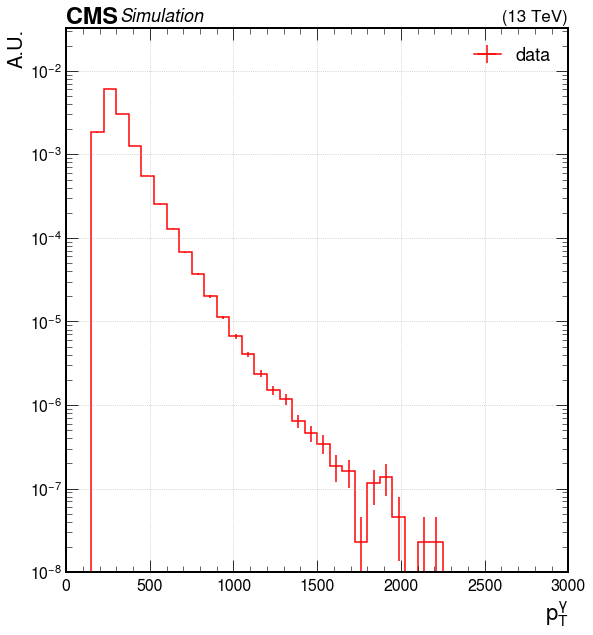

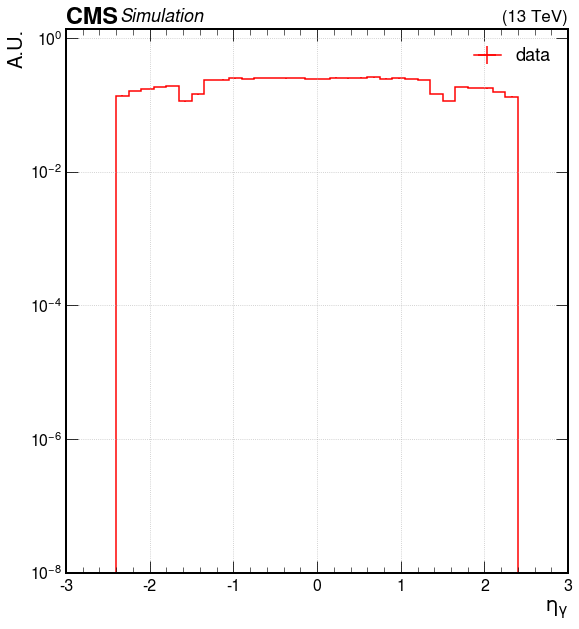

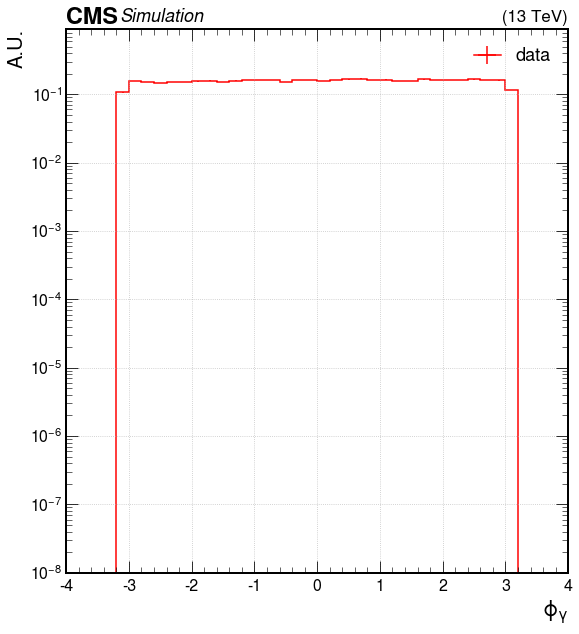

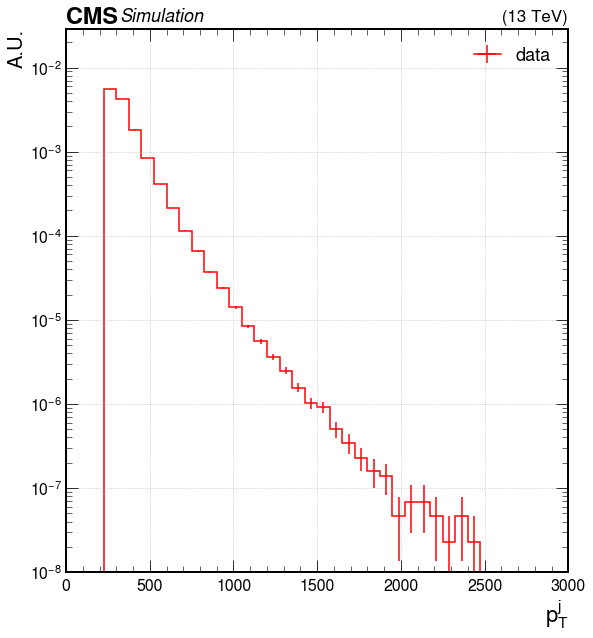

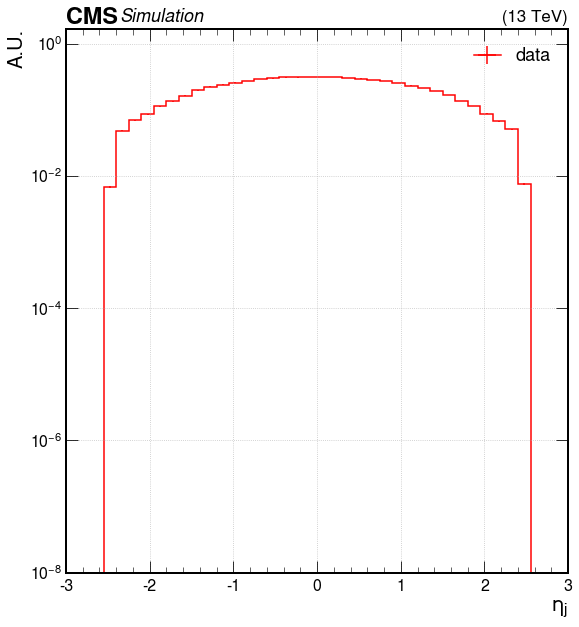

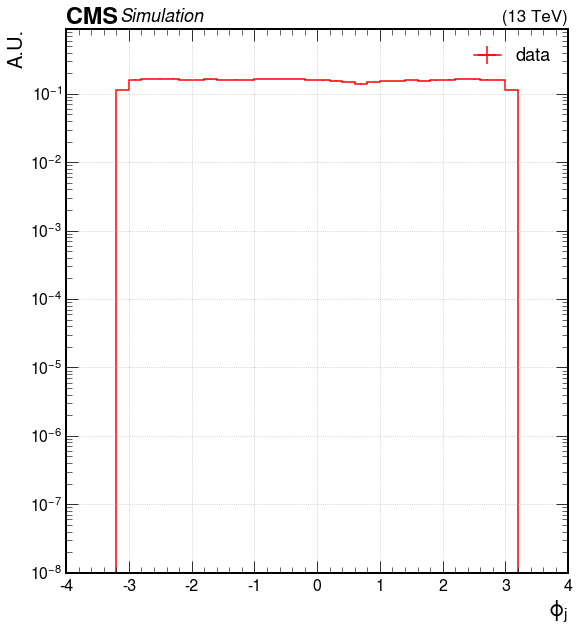

In [28]:
arrays={k: events[k].photon_pt for k in events if k.startswith('data')}
data_compare_plot(arrays, 'data_compare_photon_pt', x_name=r'$p_T^\gamma$')

arrays={k: events[k].photon_eta for k in events if k.startswith('data')}
data_compare_plot(arrays, 'data_compare_photon_eta', x_name=r'$\eta_\gamma$', x_min=-3, x_max=3)

arrays={k: events[k].photon_phi for k in events if k.startswith('data')}
data_compare_plot(arrays, 'data_compare_photon_phi', x_name=r'$\phi_\gamma$', x_min=-4, x_max=4)

arrays={k: events[k].AK8jet_pt for k in events if k.startswith('data')}
data_compare_plot(arrays, 'data_compare_AK8jet_pt', x_name=r'$p_T^j$')

arrays={k: events[k].AK8jet_eta for k in events if k.startswith('data')}
data_compare_plot(arrays, 'data_compare_AK8jet_eta', x_name=r'$\eta_j$', x_min=-3, x_max=3)

arrays={k: events[k].AK8jet_phi for k in events if k.startswith('data')}
data_compare_plot(arrays, 'data_compare_AK8jet_phi', x_name=r'$\phi_j$', x_min=-4, x_max=4)

In [42]:
def plot(arrays, weight, plot_name: str, x_name: str, cuts=None, year=2018, bins=40, x_min=0, x_max=2000, density=False, overflow=True, underflow=False):
    bin_width = (x_max-x_min)/bins
    color={'ZpToHGamma': 'red', 'ZpToH(WW)Gamma': 'blue', 'ZpToH(bb)Gamma': 'green', 'ZpToH(ZZ)Gamma': 'hotpink', 'ZpToH(tautau)Gamma': 'LightSkyBlue'}
    if cuts:
        arrays = {k: v[cuts[k]] for k, v in arrays.items()}
    ## canvas initializing
    # colorlist=['red', 'blue', 'green', 'black', 'cyan', 'darkorange', 'darkviolet', 'SlateGray', 'HotPink', 'LightSkyBlue']
    # mpl.rcParams['axes.prop_cycle'] = cycler(color=colorlist)
    # f, ax = plt.subplots()
    f = plt.figure(figsize=(9, 10))
    gs = mpl.gridspec.GridSpec(3, 1, height_ratios=[5, 1, 1], hspace=0.1)
    ax = f.add_subplot(gs[0])
    ax=plt.gca()
    plt.grid()
    hep.cms.label(data=False, year=year, ax=ax, lumi=59.83, fontsize=18)
    ## Ratio panel
    ax1 = f.add_subplot(gs[1])
    ax2 = f.add_subplot(gs[2])
    ax1.grid()
    ax2.grid()
    
    ## analyze
    bkg = {'h': {}, 'var': {}}
    sig = {'h': {}, 'var': {}}
    
    for (k,v) in arrays.items():
        hist = bh.Histogram(bh.axis.Regular(bins, x_min, x_max), storage=bh.storage.Weight())
        if 'delta_phi' in plot_name:
            values = np.min([v, 2*np.pi-v], axis=0)
        values = ak.fill_none(v, -999)
        
        if k!='data':
            hist.fill(values, weight=weight[k])
        else:
            hist.fill(values)
        h, var = flow(hist=hist, overflow=overflow, underflow=underflow)
        if k in BKG: 
            bkg['h'][k] = h
            bkg['var'][k] = var
        elif k=='data' or k in color:
            sig['h'][k] = h
            sig['var'][k] = var
        
    ## plot
    ax1.plot([x_min,x_max], [1,1], color='black', linestyle='dashed')
    # or you can specify color='blue' in the above function to cover colorlist (you could comment out colorlist too) 
    hep.histplot(list(bkg['h'].values()), bins=hist.axes[0].edges, label=list(bkg['h'].keys()), histtype='fill', density=density, stack=True, linewidth=2, ax=ax)
    bkg_h = np.sum(list(bkg['h'].values()), axis=0)
    bkg_var = np.sum(list(bkg['var'].values()), axis=0)
    for (k,v) in sig['h'].items():
        if k=='data':
            hep.histplot(v, bins=hist.axes[0].edges, yerr=np.sqrt(sig['var'][k]), label=k, color='black', histtype='errorbar', density=density, stack=False, ax=ax)
            continue
        hep.histplot(v, bins=hist.axes[0].edges, yerr=np.sqrt(sig['var'][k]), label=k, histtype='step', density=density, stack=False, linewidth=2, ax=ax)
        y = v/np.sqrt(bkg_h+1)
        yerr = y*np.sqrt(sig['var'][k]/(v**2) + 0.25/bkg_h)
        hep.histplot(y, bins=hist.axes[0].edges, xerr=bin_width/2, yerr=yerr, label=k, histtype='step', density=density, stack=False, ax=ax2, color=color[k])
    hep.histplot(sig['h']['data']/np.sum(list(bkg['h'].values()), axis=0), bins=hist.axes[0].edges, histtype='errorbar', density=density, stack=False, ax=ax1, color='black')

    ## axises
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(0.01, ax.get_ylim()[1]*1e2)
    ax.set_yscale('log')
    #ax.ticklabel_format(useOffset=False, style='scientific')
    ax.tick_params(axis='both', which='major', labelsize=16)
    #x_major_locator=plt.MultipleLocator(bin_width*8 if variable=='fj_gen_mass' else bin_width*2)
    #y_major_locator=MultipleLocator(1)
    #ax.xaxis.set_major_locator(x_major_locator)
    #ax.yaxis.set_major_locator(y_major_locator)
    if density==False:
        ax.set_ylabel('Events', fontsize=20, ha='right', y=1)
    elif density==True:    
        ax.set_ylabel('A.U.', fontsize=20, ha='right', y=1)
    ax1.set_ylabel('Data/MC', ha='center', fontsize=18)
    ax1.set_xlim(x_min, x_max)
    ax1.set_ylim(0, 2)
    ax1.ticklabel_format(useOffset=False, style='plain')
    ax1.tick_params(axis='both', which='major', labelsize=16)
    #ax2.set_yscale('log')
    ax2.tick_params(axis='both', which='major', labelsize=16)
    ax2.set_xlabel(x_name, fontsize=22, ha='right', x=1)
    ax2.set_ylabel(r'$S/\sqrt{B+1}$', ha='center', fontsize=20)
    ax2.set_xlim(x_min,x_max)
    ax2.set_ylim(0, 3)
    ax2.ticklabel_format(useOffset=False, style='plain')
    #ax2.set_yscale('log')
    ax2.tick_params(axis='both', which='major', labelsize=16)

    plt.xticks(size=16)
    plt.yticks(size=16)

    ## title, text and legend
    # plt.title('ROC Curve of HWW4q vs. QCD', fontsize=24,color="black")
    ax.legend(loc="best", ncol=2, frameon=False, fontsize=16)
    # plt.text(0.96*ax.get_xlim()[1], ax.get_ylim()[1]*0.72,"At "+r"$\mathrm{m^{gen}_{H}=}$"+f"{Higgsmass} GeV", fontsize=24, color="black", ha='right')

    ## finalizing
    suffix = '_AU' if density else ''
    if not os.path.exists('./plots'):
        os.makedirs('./plots')
    plt.savefig("./plots/"+plot_name+suffix+".pdf", bbox_inches='tight')
    plt.show()

In [30]:
print(events['data'].fields)
events.keys()

['AK8jet_eta', 'AK8jet_phi', 'AK8jet_msoftdrop', 'AK8jet_pt', 'AK8jet_mass', 'photon_eta', 'photon_phi', 'photon_pt', 'photon_mass', 'event_genWeight', 'event_MET_pt', 'photon-jet_eta', 'photon-jet_phi', 'photon-jet_pt', 'photon-jet_mass', 'photon-jet_deltaR']


dict_keys(['data', 'QCD_HT2000toInf', 'QCD_HT1500to2000', 'QCD_HT1000to1500', 'QCD_HT700to1000', 'QCD_HT500to700', 'QCD_HT300to500', 'GJets_HT-600ToInf', 'GJets_HT-400To600', 'GJets_HT-200To400', 'GJets_HT-100To200'])

/tmp/dfu/ipykernel_25105/2244097315.py:58: RuntimeWarning: divide by zero encountered in true_divide
  hep.histplot(sig['h']['data']/np.sum(list(bkg['h'].values()), axis=0), bins=hist.axes[0].edges, histtype='errorbar', density=density, stack=False, ax=ax1, color='black')
/tmp/dfu/ipykernel_25105/2244097315.py:58: RuntimeWarning: invalid value encountered in true_divide
  hep.histplot(sig['h']['data']/np.sum(list(bkg['h'].values()), axis=0), bins=hist.axes[0].edges, histtype='errorbar', density=density, stack=False, ax=ax1, color='black')


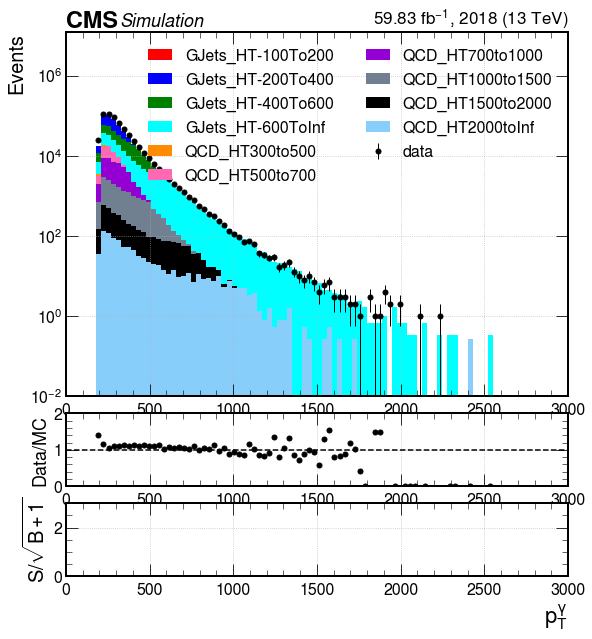

/tmp/dfu/ipykernel_25105/2244097315.py:58: RuntimeWarning: invalid value encountered in true_divide
  hep.histplot(sig['h']['data']/np.sum(list(bkg['h'].values()), axis=0), bins=hist.axes[0].edges, histtype='errorbar', density=density, stack=False, ax=ax1, color='black')


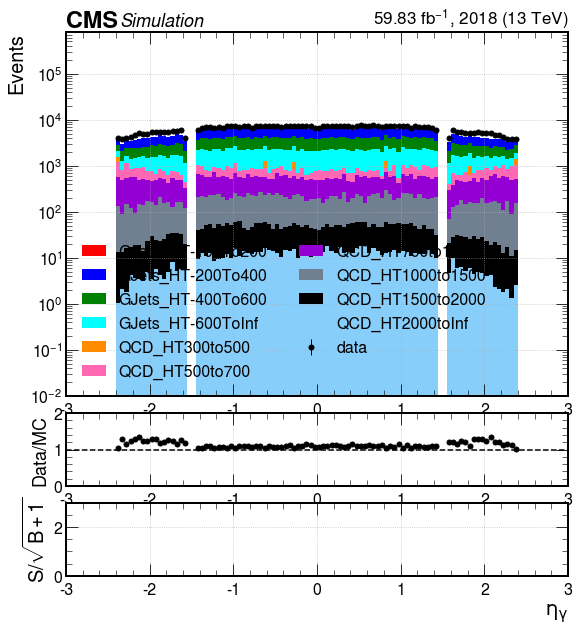

/tmp/dfu/ipykernel_25105/2244097315.py:58: RuntimeWarning: invalid value encountered in true_divide
  hep.histplot(sig['h']['data']/np.sum(list(bkg['h'].values()), axis=0), bins=hist.axes[0].edges, histtype='errorbar', density=density, stack=False, ax=ax1, color='black')


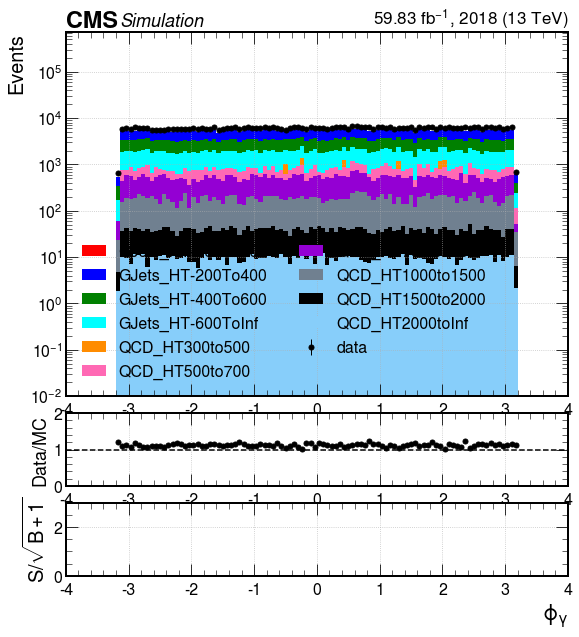

/tmp/dfu/ipykernel_25105/2244097315.py:58: RuntimeWarning: invalid value encountered in true_divide
  hep.histplot(sig['h']['data']/np.sum(list(bkg['h'].values()), axis=0), bins=hist.axes[0].edges, histtype='errorbar', density=density, stack=False, ax=ax1, color='black')


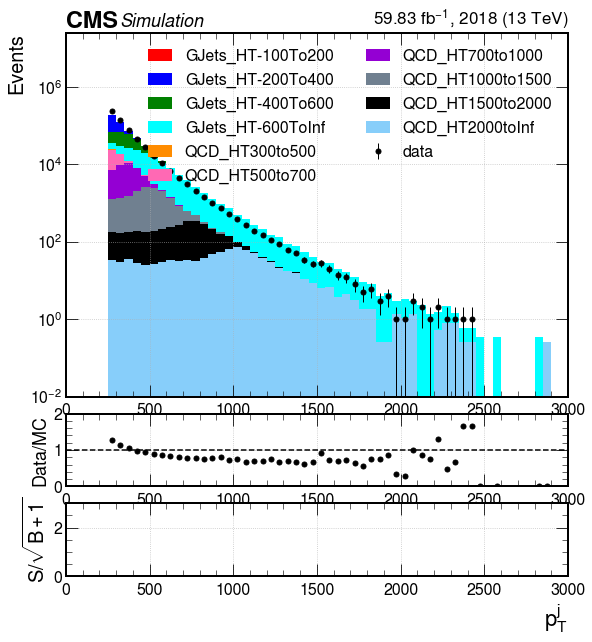

/tmp/dfu/ipykernel_25105/2244097315.py:58: RuntimeWarning: divide by zero encountered in true_divide
  hep.histplot(sig['h']['data']/np.sum(list(bkg['h'].values()), axis=0), bins=hist.axes[0].edges, histtype='errorbar', density=density, stack=False, ax=ax1, color='black')
/tmp/dfu/ipykernel_25105/2244097315.py:58: RuntimeWarning: invalid value encountered in true_divide
  hep.histplot(sig['h']['data']/np.sum(list(bkg['h'].values()), axis=0), bins=hist.axes[0].edges, histtype='errorbar', density=density, stack=False, ax=ax1, color='black')


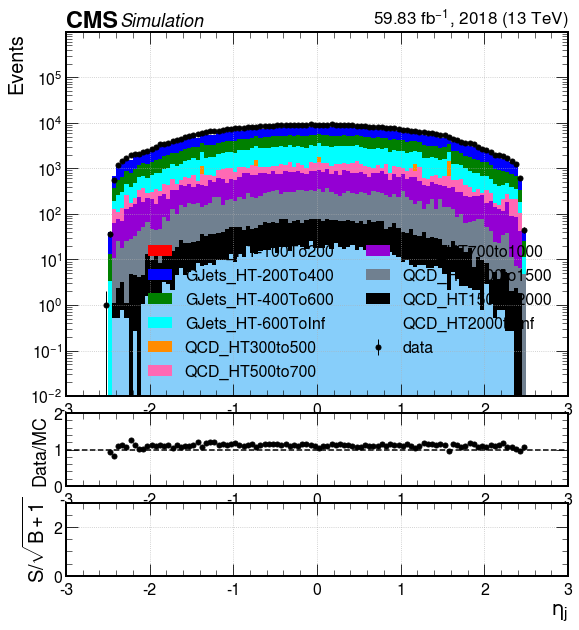

/tmp/dfu/ipykernel_25105/2244097315.py:58: RuntimeWarning: invalid value encountered in true_divide
  hep.histplot(sig['h']['data']/np.sum(list(bkg['h'].values()), axis=0), bins=hist.axes[0].edges, histtype='errorbar', density=density, stack=False, ax=ax1, color='black')


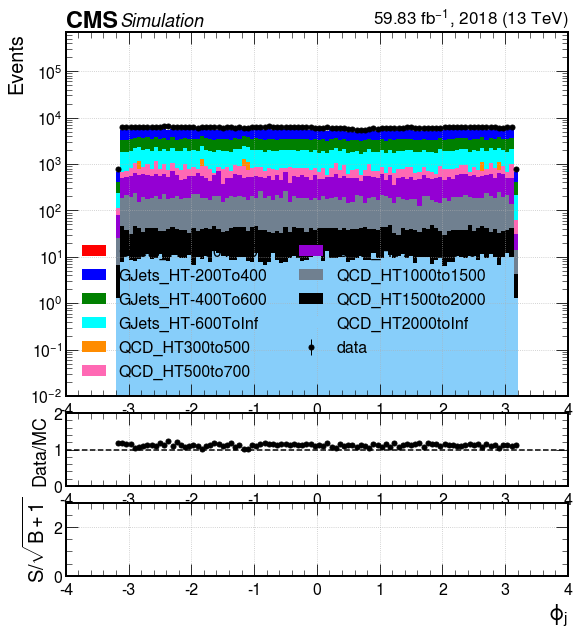

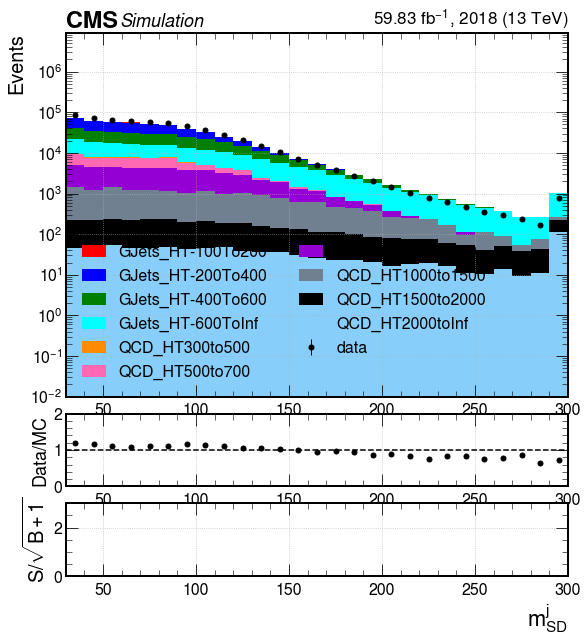

In [49]:
#leading_photon = {k: ak.argmax(events[k].leading_photon_pt, axis=1, keepdims=True) for k in events}
#heaviest_AK8jet = {k: ak.argmax(events[k].heaviest_jet_msoftdrop, axis=1, keepdims=True) for k in events}

arrays={k: events[k].photon_pt for k in events}
plot(arrays, plot_name='photon_pt', x_name=r'$p_T^{\gamma}$', x_max=3000, x_min=0, bins=100, weight=weight)
arrays={k: events[k].photon_eta for k in events}
plot(arrays, plot_name='photon_eta', x_name=r'$\eta_{\gamma}$', x_max=3, x_min=-3, bins=120, weight=weight)
arrays={k: events[k].photon_phi for k in events}
plot(arrays, plot_name='photon_phi', x_name=r'$\phi_{\gamma}$', x_max=4, x_min=-4, bins=120, weight=weight)
arrays={k: events[k].AK8jet_pt for k in events}
plot(arrays, plot_name='AK8jet_pt', x_name=r'$p_T^{j}$', x_max=3000, x_min=0, bins=60, weight=weight)
arrays={k: events[k].AK8jet_eta for k in events}
plot(arrays, plot_name='AK8jet_eta', x_name=r'$\eta_j$', x_max=3, x_min=-3, bins=120, weight=weight)
arrays={k: events[k].AK8jet_phi for k in events}
plot(arrays, plot_name='AK8jet_phi', x_name=r'$\phi_j$', x_max=4, x_min=-4, bins=120, weight=weight)
arrays={k: events[k].AK8jet_msoftdrop for k in events}
plot(arrays, plot_name='AK8jet_msoftdrop', x_name=r'$m_{SD}^{j}$', x_max=300, x_min=30, bins=27, weight=weight)

/tmp/dfu/ipykernel_25105/2244097315.py:58: RuntimeWarning: invalid value encountered in true_divide
  hep.histplot(sig['h']['data']/np.sum(list(bkg['h'].values()), axis=0), bins=hist.axes[0].edges, histtype='errorbar', density=density, stack=False, ax=ax1, color='black')


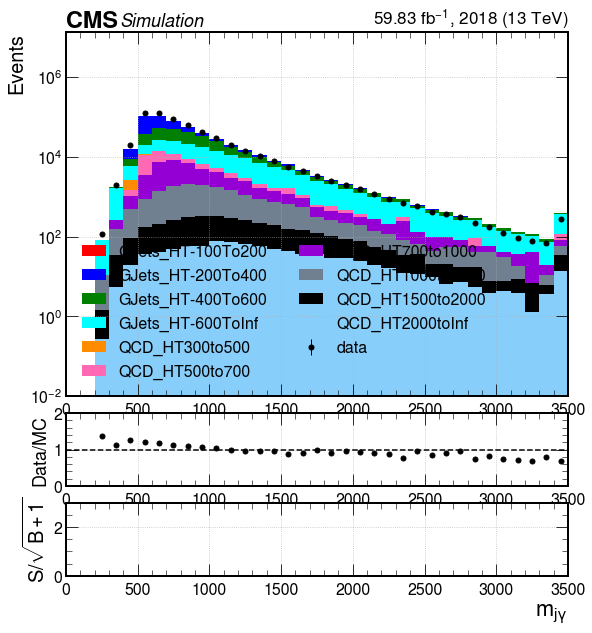

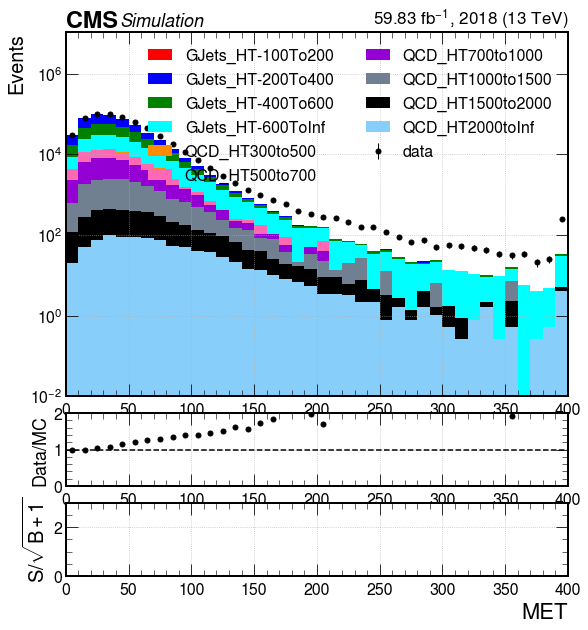

/tmp/dfu/ipykernel_25105/2244097315.py:58: RuntimeWarning: invalid value encountered in true_divide
  hep.histplot(sig['h']['data']/np.sum(list(bkg['h'].values()), axis=0), bins=hist.axes[0].edges, histtype='errorbar', density=density, stack=False, ax=ax1, color='black')


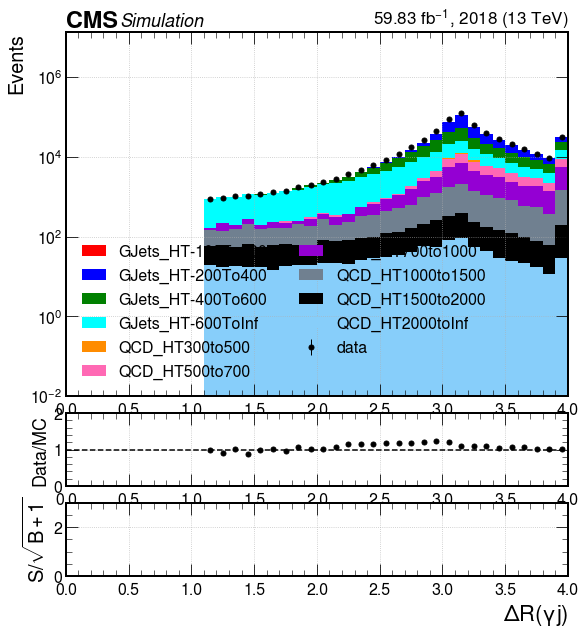

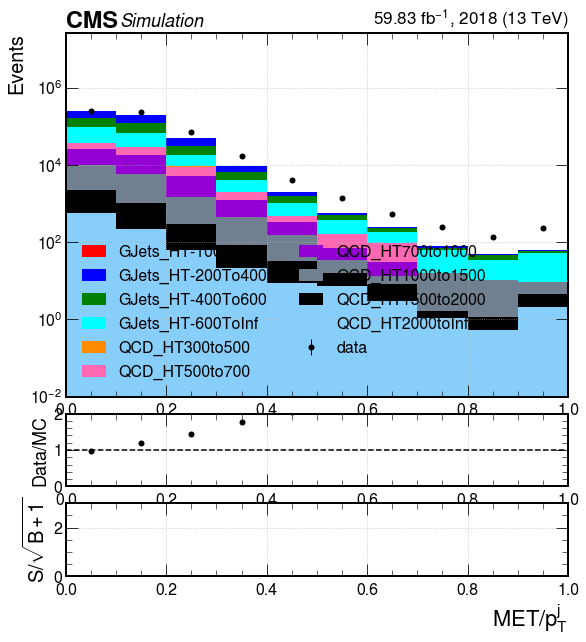

In [50]:
arrays={k: events[k]['photon-jet_mass'] for k in events}
plot(arrays, x_name=r'$m_{j\gamma}$', plot_name='photon-jet_mass', x_max=3500, bins=35, weight=weight)
arrays={k: events[k]['event_MET_pt'] for k in events}
plot(arrays, x_name='MET', plot_name='event_MET_pt', x_max=400, bins=40, weight=weight)
arrays={k: events[k]['photon-jet_deltaR'] for k in events}
plot(arrays, x_name=r'$\Delta R(\gamma j)$', plot_name='photon-jet_deltaR', x_max=4, bins=40, weight=weight)
arrays={k: events[k].event_MET_pt/events[k].AK8jet_pt for k in events}
plot(arrays, plot_name='MET_over_AK8jet_pt', x_name=r'$MET/p_T^{j}$', x_max=1, x_min=0, bins=10, weight=weight)

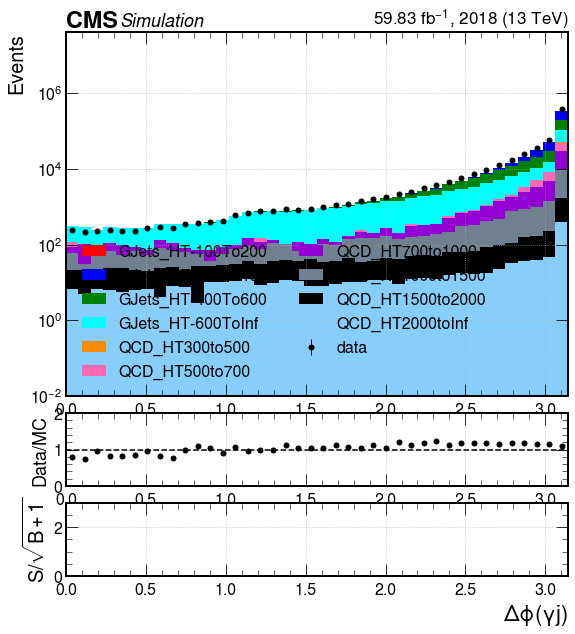

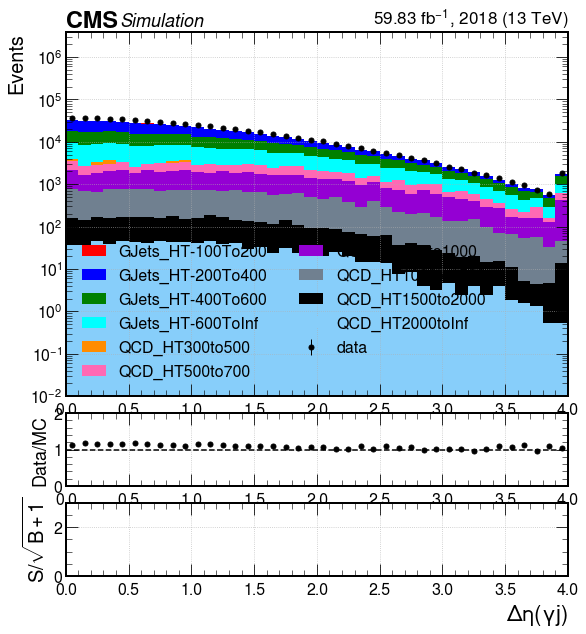

In [51]:
arrays={k: abs(events[k].photon_phi - events[k].AK8jet_phi) for k in events}
plot(arrays, plot_name='photon-jet_delta_phi', x_name=r'$\Delta \phi(\gamma j)$', x_max=np.pi, bins=40, weight=weight)
arrays={k: abs(events[k].photon_eta - events[k].AK8jet_eta) for k in events}
plot(arrays, plot_name='photon-jet_delta_eta', x_name=r'$\Delta \eta(\gamma j)$', x_max=4, bins=40, weight=weight)